In [1]:
from ase.io import read
from ase.eos import EquationOfState
from pathlib import Path
from ase import Atoms
import numpy as np

In [2]:
# Load all data

base_dir = Path("/home/jvc/ZnO_database/scripts/PBEU_000_OUTPUTS-111")
atoms: list[Atoms] = [read(f) for f in sorted(base_dir.rglob("*.out"))]

V = np.array([atom.get_volume() / 2 for atom in atoms])
E = np.array([atom.get_total_energy() / 2 for atom in atoms])


---

<h2>Murnaghan equation</h2>

$$

E(V) = E_0 - \frac{B_0 V_0}{B' - 1} + \frac{B_0 V}{B'} \left [\frac{(V_0/V)^{B'}}{B' - 1} + 1\right]

$$

onde $E_0$, $V_0$ e $B_0$ são a energia total, o volume por unidade de fórmula de ZnO e o módulo de compressibilidade a pressão zero (P), respectivamente, e assume-se que $B' = dB/dP$ seja constante.


In [3]:
import matplotlib.pyplot as plt
plt.style.use("/home/jvc/ZnO_database/mpl_themes/jvc.mplstyle")

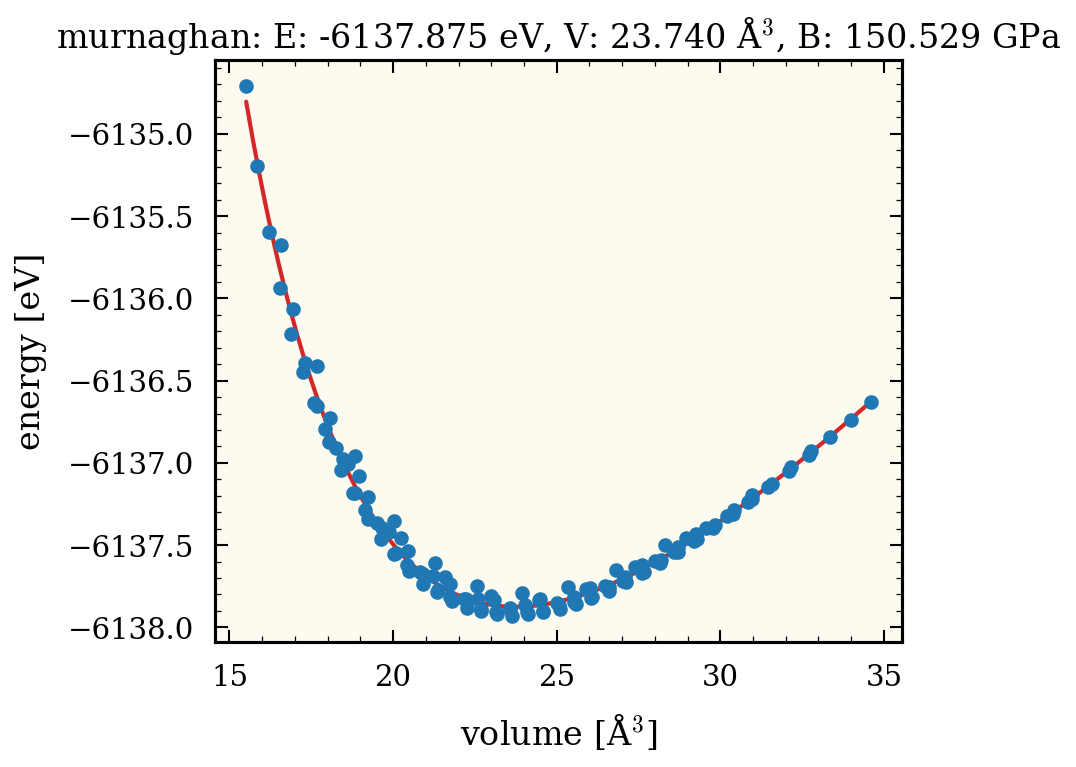

In [10]:
eos = EquationOfState(V, E, eos="murnaghan")
v0, e0, B = eos.fit()

fig, ax = plt.subplots(dpi=150, layout="constrained")
ax = eos.plot(show=False,ax=ax)

plt.show()

<h2> Birch–Murnaghan </h2>

$$ E(V)=E_{0}+{\frac {9V_{0}B_{0}}{16}}\left\{\left[\left({\frac {V_{0}}{V}}\right)^{2/3}-1\right]^{3}B_{0}^{\prime }+\left[\left({\frac {V_{0}}{V}}\right)^{2/3}-1\right]^{2}\left[6-4\left({\frac {V_{0}}{V}}\right)^{2/3}\right]\right\} $$

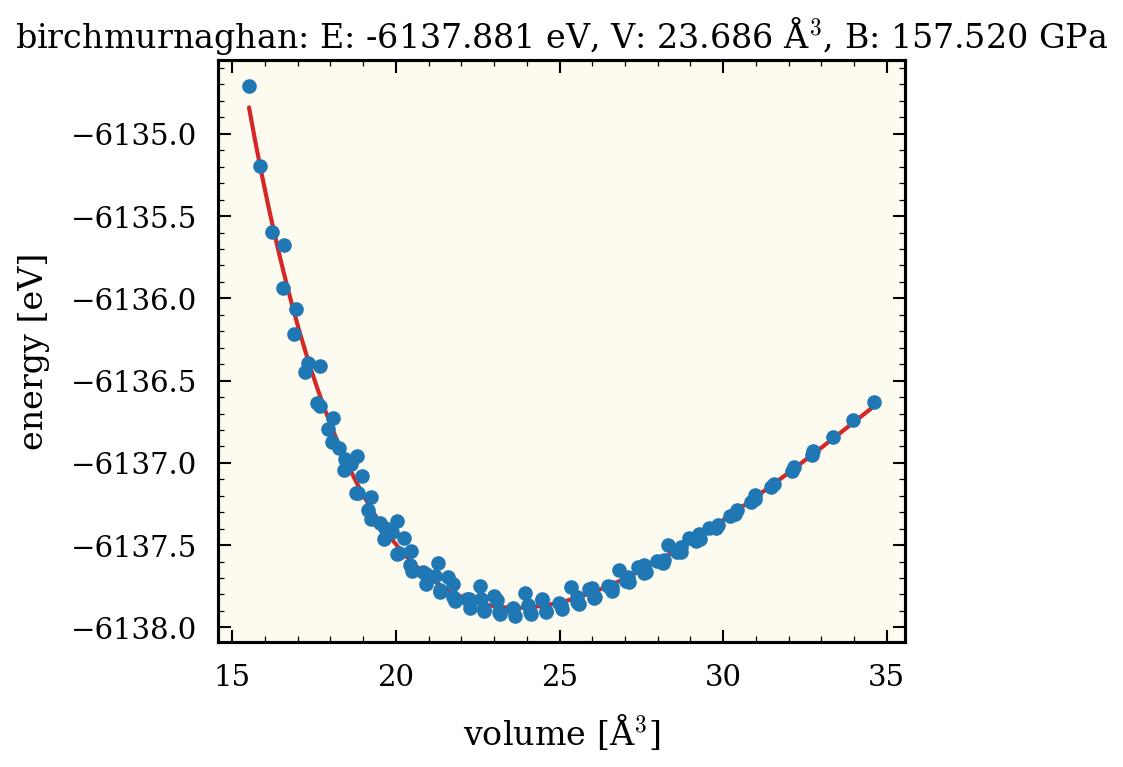

In [11]:

eos = EquationOfState(V, E, eos="birchmurnaghan")

v0, e0, B = eos.fit()

fig, ax = plt.subplots(dpi=150, layout="constrained")
ax = eos.plot(show=False,ax=ax)
plt.show()

---